# Why Linear Regression Can Be a Misfit for Delivery Time Prediction

## Use Case
We want to predict **Delivery Time** using logistics inputs such as:

- Distance in km
- Gross Weight in kg
- Traffic Level

This notebook shows **why Linear Regression may fail** when the delivery-time problem is **non-linear and rule-based**, and why **Decision Tree Regression becomes more suitable**.

## Core Learning Objective

Linear Regression works best when the relationship is close to a straight line.

But delivery time is often affected by conditions such as:

- Traffic level suddenly increasing travel time
- Long-distance routes using different delivery patterns
- Heavy shipments requiring extra handling time
- Delay rules based on slabs or thresholds

Decision Tree Regression can learn such rules using **if-else splits**.


In [2]:
# ============================================================
# 1. Import Required Libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

print("Libraries imported successfully.")


Libraries imported successfully.


# 2. Create a Rule-Based Dataset

We will create a synthetic logistics dataset with **500 records**.

The dataset includes:

| Column | Meaning |
|---|---|
| Distance_km | Distance between pickup and delivery location |
| Gross_Weight_kg | Shipment weight |
| Traffic_Level | Low, Medium, or High |
| Delivery_Time_hr | Actual delivery time in hours |

The dataset is intentionally created with **business rules**, not a simple straight-line pattern.


In [3]:
# ============================================================
# 2. Generate Dataset
# ============================================================

n_records = 500

distance = np.random.uniform(5, 500, n_records).round(1)
gross_weight = np.random.uniform(10, 5000, n_records).round(1)
traffic_level = np.random.choice(["Low", "Medium", "High"], size=n_records, p=[0.35, 0.40, 0.25])

delivery_time = []

for d, w, traffic in zip(distance, gross_weight, traffic_level):
    # Base rule by distance slabs
    if d <= 50:
        time = 2 + 0.03 * d
    elif d <= 150:
        time = 5 + 0.06 * d
    elif d <= 300:
        time = 12 + 0.04 * d
    else:
        time = 20 + 0.025 * d

    # Traffic-based non-linear impact
    if traffic == "Low":
        time += 0
    elif traffic == "Medium":
        time += 4
    else:
        time += 12

    # Heavy shipment threshold impact
    if w > 3000:
        time += 8
    elif w > 1500:
        time += 3

    # Extra rule: short high-traffic deliveries become disproportionately delayed
    if d < 80 and traffic == "High":
        time += 10

    # Random noise
    time += np.random.normal(0, 1.8)

    delivery_time.append(round(max(time, 1), 2))

df = pd.DataFrame({
    "Distance_km": distance,
    "Gross_Weight_kg": gross_weight,
    "Traffic_Level": traffic_level,
    "Delivery_Time_hr": delivery_time
})

df.head()


,Distance_km,Gross_Weight_kg,Traffic_Level,Delivery_Time_hr
0,190.4,3493.8,Low,23.12
1,475.6,2685.1,Medium,43.01
2,367.3,1554.5,High,41.68
3,301.3,4070.8,Medium,36.57
4,82.2,3426.8,High,31.77


In [4]:
# Dataset shape and sample records
print("Dataset shape:", df.shape)
display(df.head(10))
display(df.describe())


Dataset shape: (500, 4)


,Distance_km,Gross_Weight_kg,Traffic_Level,Delivery_Time_hr
0,190.4,3493.8,Low,23.12
1,475.6,2685.1,Medium,43.01
2,367.3,1554.5,High,41.68
3,301.3,4070.8,Medium,36.57
4,82.2,3426.8,High,31.77
5,82.2,821.5,Medium,18.32
6,33.8,4555.5,Medium,17.51
7,433.8,4114.5,High,51.86
8,302.6,4749.5,Low,36.64
9,355.5,3631.3,Medium,42.42


,Distance_km,Gross_Weight_kg,Delivery_Time_hr
count,500.000000,500.000000,500.000000
mean,251.787000,2414.940200,30.086420
std,147.852427,1424.613063,11.345083
min,7.500000,33.100000,1.000000
25%,124.425000,1153.225000,22.937500
50%,259.000000,2364.400000,31.655000
75%,379.275000,3634.400000,38.702500
max,496.500000,4998.600000,53.580000


# 3. Visualize the Dataset

Observe that delivery time does **not** follow one clean straight line.

Why?

Because delivery time changes based on:

- Distance slabs
- Traffic levels
- Heavy-weight thresholds
- Combined business conditions


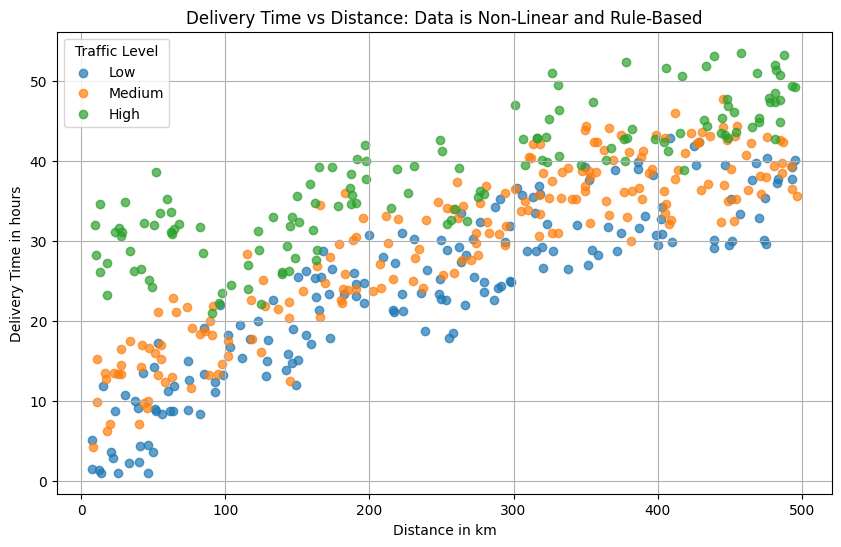

In [5]:
# ============================================================
# 3. Visualize Distance vs Delivery Time
# ============================================================

plt.figure(figsize=(10, 6))

for traffic in ["Low", "Medium", "High"]:
    subset = df[df["Traffic_Level"] == traffic]
    plt.scatter(
        subset["Distance_km"],
        subset["Delivery_Time_hr"],
        label=traffic,
        alpha=0.7
    )

plt.xlabel("Distance in km")
plt.ylabel("Delivery Time in hours")
plt.title("Delivery Time vs Distance: Data is Non-Linear and Rule-Based")
plt.legend(title="Traffic Level")
plt.grid(True)
plt.show()


# 4. Prepare Data for Machine Learning

Input variables:

- Distance_km
- Gross_Weight_kg
- Traffic_Level

Output variable:

- Delivery_Time_hr

Since **Traffic_Level** is categorical, we apply **One-Hot Encoding**.


In [6]:
# ============================================================
# 4. Train-Test Split and Preprocessing
# ============================================================

X = df[["Distance_km", "Gross_Weight_kg", "Traffic_Level"]]
y = df["Delivery_Time_hr"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_features = ["Distance_km", "Gross_Weight_kg"]
categorical_features = ["Traffic_Level"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])


Training records: 400
Testing records: 100


# 5. Train Linear Regression Model

Linear Regression tries to fit one equation:

\[
Delivery\ Time = b + w_1x_1 + w_2x_2 + ...
\]

This is useful when the relationship is linear.

But here, delivery time changes in slabs and conditions.


In [7]:
# ============================================================
# 5. Linear Regression Model
# ============================================================

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R²  :", round(r2_lr, 4))


Linear Regression Performance
--------------------------------
MAE : 3.29
RMSE: 3.94
R²  : 0.8635


# 6. Report Linear Regression Equation

The equation is derived after training.

Because Traffic_Level is categorical, it is converted into dummy variables.

With `drop='first'`, one traffic level becomes the base category.


In [8]:
# ============================================================
# 6. Report Linear Regression Equation
# ============================================================

trained_preprocessor = linear_model.named_steps["preprocessor"]
trained_regressor = linear_model.named_steps["model"]

encoded_cat_features = trained_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = list(encoded_cat_features) + numeric_features

coefficients = trained_regressor.coef_
intercept = trained_regressor.intercept_

print("Bias / Intercept:", round(intercept, 4))
print("\nWeights / Coefficients:")
for feature, coef in zip(all_feature_names, coefficients):
    print(f"{feature}: {coef:.4f}")

equation = "Delivery_Time_hr = " + str(round(intercept, 4))
for feature, coef in zip(all_feature_names, coefficients):
    sign = " + " if coef >= 0 else " - "
    equation += sign + str(round(abs(coef), 4)) + " * " + feature

print("\nLinear Regression Equation:")
print(equation)


Bias / Intercept: 17.3061

Weights / Coefficients:
Traffic_Level_Low: -13.5383
Traffic_Level_Medium: -8.9462
Distance_km: 0.0590
Gross_Weight_kg: 0.0024

Linear Regression Equation:
Delivery_Time_hr = 17.3061 - 13.5383 * Traffic_Level_Low - 8.9462 * Traffic_Level_Medium + 0.059 * Distance_km + 0.0024 * Gross_Weight_kg


# 7. Why Linear Regression is a Misfit

A linear model creates one smooth straight-line relationship.

But our delivery time has jumps:

- High traffic adds a large delay
- Weight above a threshold adds extra handling time
- Distance slabs behave differently
- Short-distance high-traffic deliveries behave differently

So Linear Regression averages these effects and misses the actual business rules.


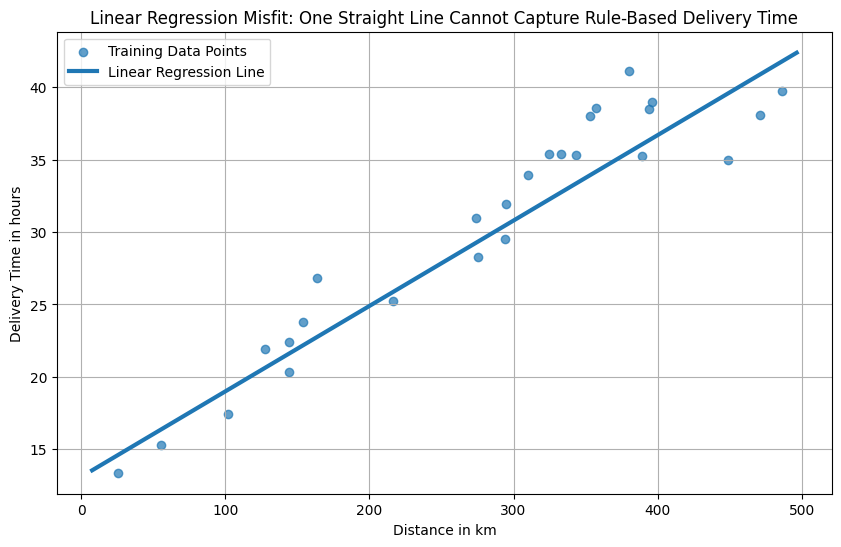

In [9]:
# ============================================================
# 7. Plot Linear Regression Line vs Training Data
# Holding Gross Weight and Traffic Level Constant
# ============================================================

fixed_weight = 2000
fixed_traffic = "Medium"

distance_range = np.linspace(df["Distance_km"].min(), df["Distance_km"].max(), 200)

plot_df = pd.DataFrame({
    "Distance_km": distance_range,
    "Gross_Weight_kg": fixed_weight,
    "Traffic_Level": fixed_traffic
})

lr_line = linear_model.predict(plot_df)

train_subset = X_train.copy()
train_subset["Delivery_Time_hr"] = y_train.values

subset_for_plot = train_subset[
    (train_subset["Traffic_Level"] == fixed_traffic) &
    (train_subset["Gross_Weight_kg"].between(1500, 2500))
]

plt.figure(figsize=(10, 6))
plt.scatter(
    subset_for_plot["Distance_km"],
    subset_for_plot["Delivery_Time_hr"],
    alpha=0.7,
    label="Training Data Points"
)
plt.plot(
    distance_range,
    lr_line,
    linewidth=3,
    label="Linear Regression Line"
)

plt.xlabel("Distance in km")
plt.ylabel("Delivery Time in hours")
plt.title("Linear Regression Misfit: One Straight Line Cannot Capture Rule-Based Delivery Time")
plt.legend()
plt.grid(True)
plt.show()


# 8. Train Decision Tree Regression Model

Decision Tree Regression learns by asking questions such as:

- Is traffic level high?
- Is distance greater than 150 km?
- Is gross weight greater than 3000 kg?

This makes it more suitable for rule-based delivery-time problems.


In [10]:
# ============================================================
# 8. Decision Tree Regression Model
# ============================================================

tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=6,
        min_samples_leaf=8,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

y_pred_dt = tree_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regression Performance")
print("------------------------------------")
print("MAE :", round(mae_dt, 2))
print("RMSE:", round(rmse_dt, 2))
print("R²  :", round(r2_dt, 4))


Decision Tree Regression Performance
------------------------------------
MAE : 2.56
RMSE: 3.23
R²  : 0.9082


# 9. Compare Linear Regression vs Decision Tree Regression

Lower MAE and RMSE are better.

Higher R² is better.


In [11]:
# ============================================================
# 9. Model Comparison
# ============================================================

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree Regression"],
    "MAE": [mae_lr, mae_dt],
    "RMSE": [rmse_lr, rmse_dt],
    "R2 Score": [r2_lr, r2_dt]
})

display(comparison.round(4))


,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.2886,3.9389,0.8635
1,Decision Tree Regression,2.5640,3.2309,0.9082


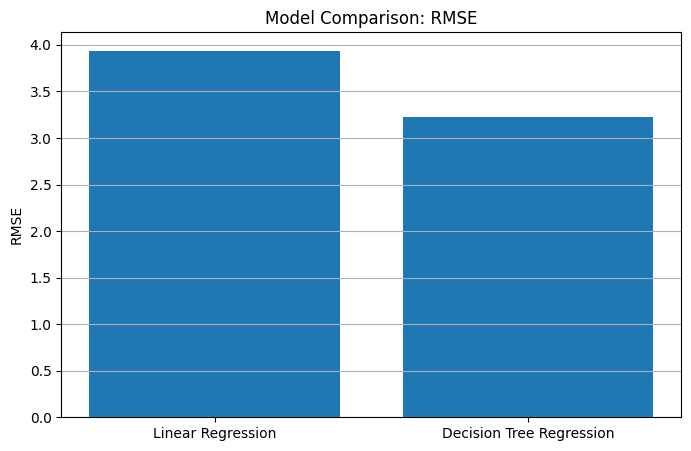

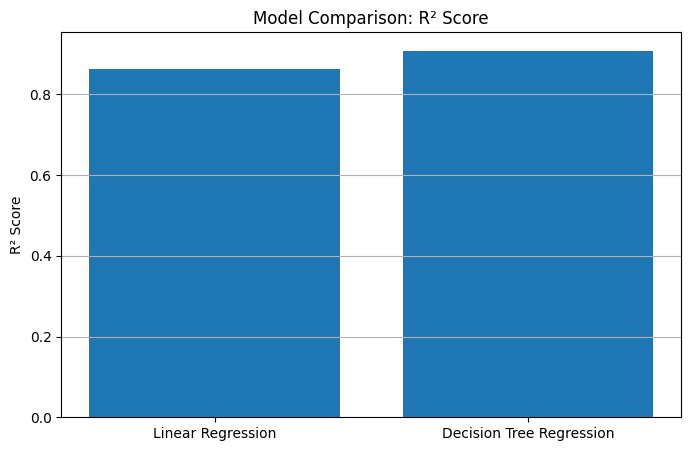

In [12]:
# Bar chart comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["RMSE"])
plt.ylabel("RMSE")
plt.title("Model Comparison: RMSE")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["R2 Score"])
plt.ylabel("R² Score")
plt.title("Model Comparison: R² Score")
plt.grid(axis="y")
plt.show()


# 10. Visualize Decision Tree Prediction Pattern

Unlike Linear Regression, Decision Tree can produce step-wise predictions based on conditions.

This is closer to real logistics rules.


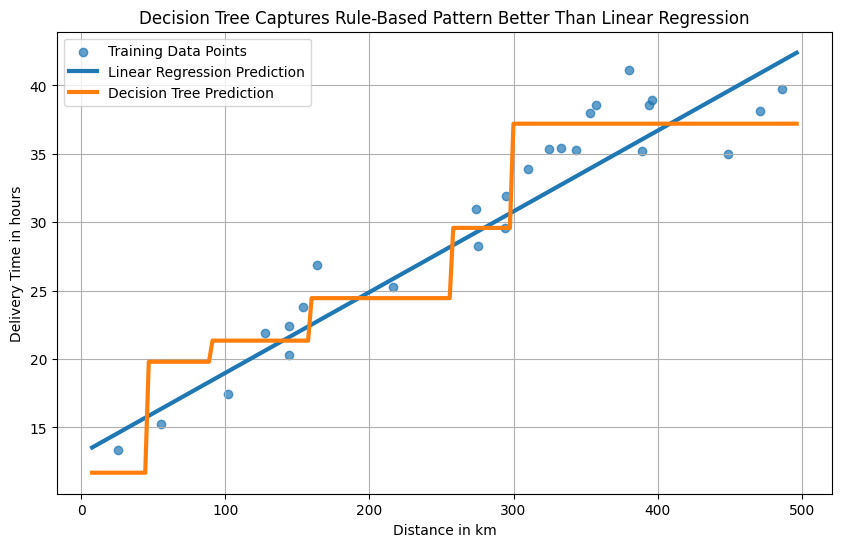

In [13]:
# ============================================================
# 10. Plot Decision Tree Prediction vs Linear Regression
# Holding Gross Weight and Traffic Level Constant
# ============================================================

dt_line = tree_model.predict(plot_df)

plt.figure(figsize=(10, 6))
plt.scatter(
    subset_for_plot["Distance_km"],
    subset_for_plot["Delivery_Time_hr"],
    alpha=0.7,
    label="Training Data Points"
)

plt.plot(
    distance_range,
    lr_line,
    linewidth=3,
    label="Linear Regression Prediction"
)

plt.plot(
    distance_range,
    dt_line,
    linewidth=3,
    label="Decision Tree Prediction"
)

plt.xlabel("Distance in km")
plt.ylabel("Delivery Time in hours")
plt.title("Decision Tree Captures Rule-Based Pattern Better Than Linear Regression")
plt.legend()
plt.grid(True)
plt.show()


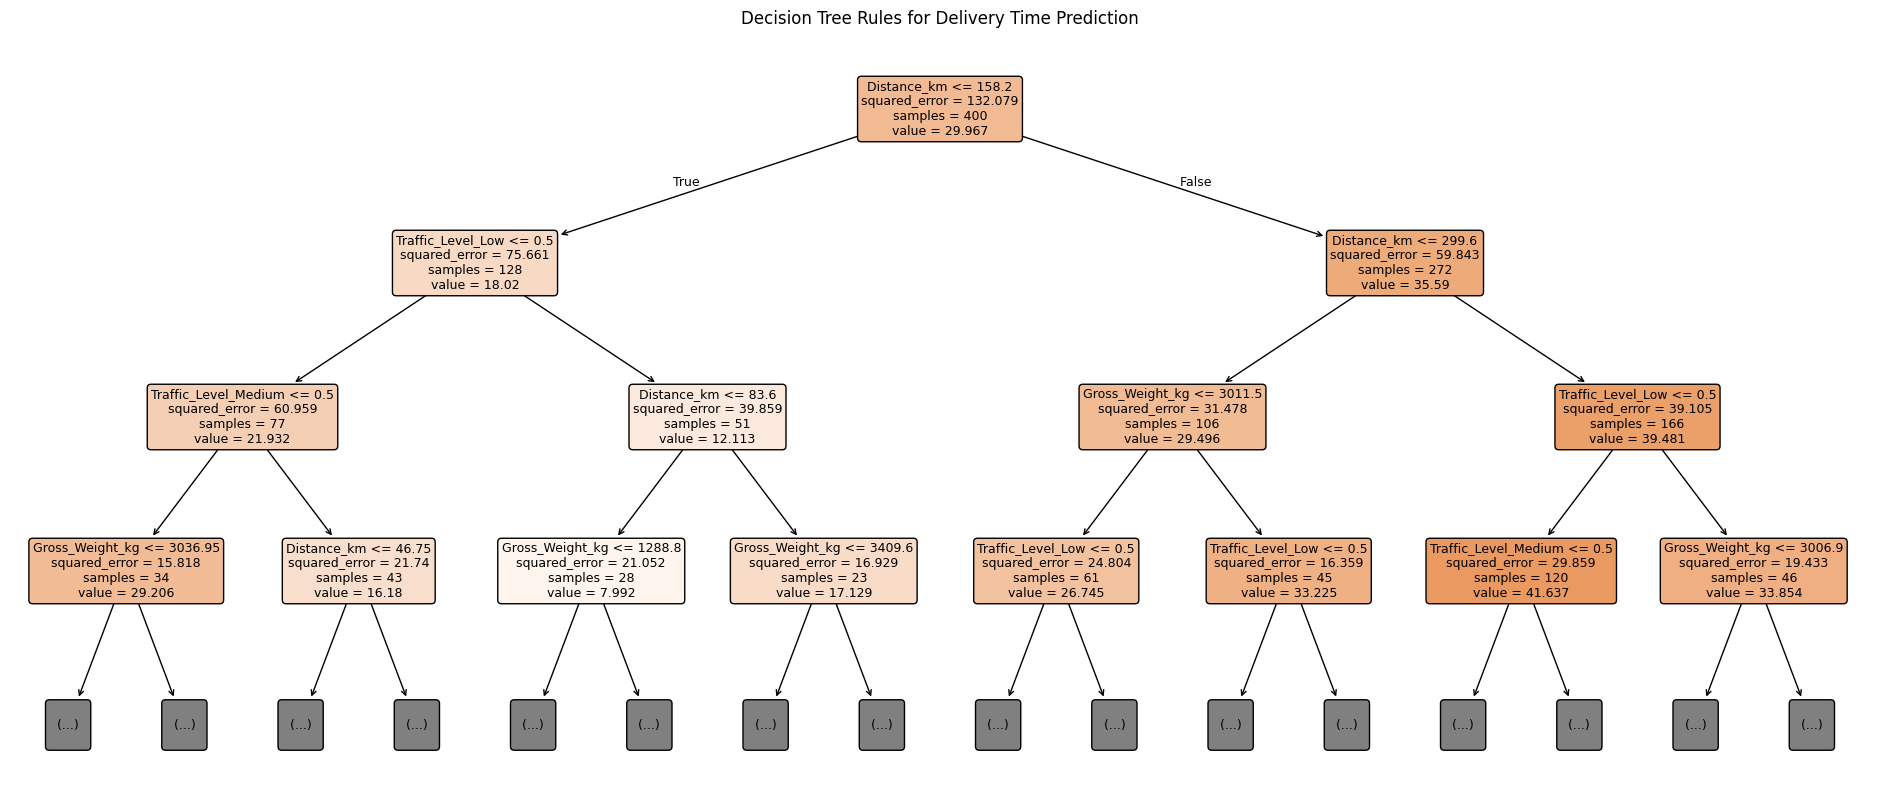

In [14]:
# ============================================================
# 11. Visualize the Decision Tree Structure
# ============================================================

feature_names = all_feature_names

plt.figure(figsize=(24, 10))
plot_tree(
    tree_model.named_steps["model"],
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Rules for Delivery Time Prediction")
plt.show()


# 12. Make Prediction on Test Data

We now compare actual delivery time with predictions from both models.


In [15]:
# ============================================================
# 12. Prediction on Test Data
# ============================================================

test_predictions = X_test.copy()
test_predictions["Actual_Delivery_Time_hr"] = y_test.values
test_predictions["Linear_Regression_Prediction_hr"] = y_pred_lr.round(2)
test_predictions["Decision_Tree_Prediction_hr"] = y_pred_dt.round(2)

display(test_predictions.head(15))


,Distance_km,Gross_Weight_kg,Traffic_Level,Actual_Delivery_Time_hr,Linear_Regression_Prediction_hr,Decision_Tree_Prediction_hr
361,323.4,2271.9,Low,32.13,28.23,28.73
73,408.7,3114.2,Low,42.86,35.26,37.80
374,40.2,136.7,Low,2.37,6.46,3.95
155,124.8,646.6,High,22.13,26.20,26.42
104,454.2,612.0,High,43.66,45.56,46.06
394,173.7,3343.7,Low,26.54,21.93,28.50
377,16.5,3298.0,Medium,13.54,17.14,11.69
124,117.8,3095.1,Medium,22.65,22.64,21.35
68,41.9,4521.8,Medium,16.99,21.53,11.69
450,389.7,3006.6,Medium,41.22,38.47,37.21


# 13. User Input Prediction

Enter your own values and compare the prediction from:

- Linear Regression
- Decision Tree Regression


In [16]:
# ============================================================
# 13. Prediction Based on User Input
# ============================================================

distance_input = float(input("Enter Distance in km: "))
weight_input = float(input("Enter Gross Weight in kg: "))
traffic_input = input("Enter Traffic Level [Low / Medium / High]: ")

user_data = pd.DataFrame({
    "Distance_km": [distance_input],
    "Gross_Weight_kg": [weight_input],
    "Traffic_Level": [traffic_input]
})

lr_prediction = linear_model.predict(user_data)[0]
dt_prediction = tree_model.predict(user_data)[0]

print("\nUser Input:")
display(user_data)

print("Predicted Delivery Time using Linear Regression:", round(lr_prediction, 2), "hours")
print("Predicted Delivery Time using Decision Tree Regression:", round(dt_prediction, 2), "hours")


Enter Distance in km: 100
Enter Gross Weight in kg: 50
Enter Traffic Level [Low / Medium / High]: Low

User Input:


,Distance_km,Gross_Weight_kg,Traffic_Level
0,100.0,50.0,Low


Predicted Delivery Time using Linear Regression: 9.79 hours
Predicted Delivery Time using Decision Tree Regression: 14.57 hours


# Final Conclusion

## Why Linear Regression is a Misfit Here

Linear Regression is a misfit because it tries to fit a single straight-line equation.

But delivery time depends on rule-based business conditions such as:

- Traffic level
- Distance slabs
- Weight thresholds
- Combined conditions

## Why Decision Tree is Required

Decision Tree Regression is better for this use case because it can split data into business-like rules:

```text
IF Traffic_Level = High AND Distance < 80 km:
    Add extra delay

IF Gross_Weight > 3000 kg:
    Add handling delay

IF Distance is in a certain slab:
    Use different delivery-time pattern
```

Therefore, when delivery time is affected by **conditions, thresholds, and non-linear patterns**, Decision Tree Regression is usually more suitable than Linear Regression.
